In [1]:
# 0,1: 00 for psi_1, 01 for psi_2 ...
# 2: For states
# 3,4: Ancillary qubits

# when theta = 32.56... 
# psi_1 = |0> 
# psi_2 = sqrt(2/3)|0> + sqrt(1/3)|1>
# psi_3 = sqrt(2/3)|0> - sqrt(1/3)|1>

In [2]:
from qiskit import QuantumCircuit, ClassicalRegister
from numpy import sqrt, array
from numpy.linalg import norm
from qiskit.circuit.library import StatePreparation
def circuit_init():
    qc = QuantumCircuit(5)
    return qc

def PREP(qc):
    desired_vector = [sqrt(1/3), 0, sqrt(2)/3, 1/3, sqrt(2)/3, -1/3, 0, 0]
    prep = StatePreparation(desired_vector)
    qc.append(prep,[2,1,0])
    return qc

def Ansatz(qc, wires, num_layers, params):
    for i in range(num_layers):
        qc.barrier()
        offset = 6 * i
        qc.rx(params[offset + 0], wires[0])
        qc.rz(params[offset + 1], wires[0])
        qc.rx(params[offset + 2], wires[1])
        qc.rz(params[offset + 3], wires[1])
        qc.rx(params[offset + 4], wires[2])
        qc.rz(params[offset + 5], wires[2])
        qc.cx(wires[0], wires[1])
        qc.cx(wires[1], wires[2])
        qc.cx(wires[2], wires[0])
    qc.measure_all()

    return qc

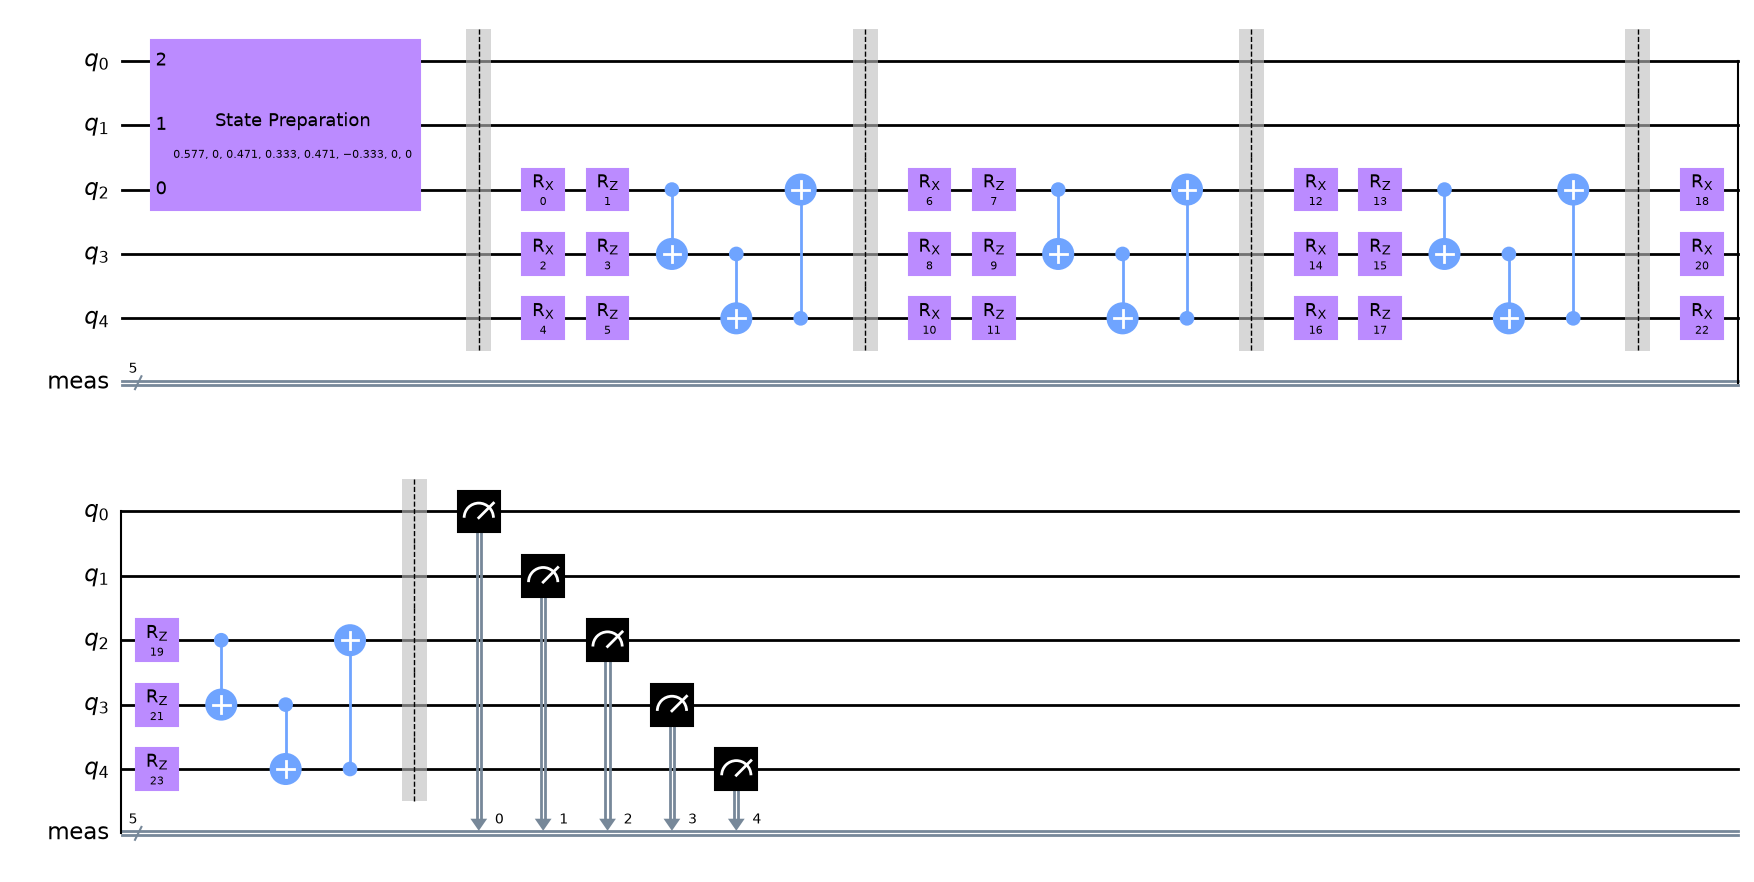

In [3]:
from numpy.random import rand
num_layers=4
num_params= 6*num_layers
params = list(range(num_params))
num_shots=10000

qc = circuit_init()
qc = PREP(qc)
Ansatz(qc, [2,3,4] , num_layers, params)

qc.draw(output='mpl', style = 'clifford') 
#qc_reversed=qc.reverse_bits()
#qc_reversed.draw(output='mpl',style = 'clifford') 

In [4]:
# ============================================================
# AWS Braket / IQM Garnet setup
# ============================================================

from braket.aws import AwsDevice
from qiskit_braket_provider import BraketProvider
from qiskit import transpile
import numpy as np

GARNET_ARN = "arn:aws:braket:eu-north-1::device/qpu/iqm/Garnet"

# Check device status. This does NOT submit a paid task.
garnet_device = AwsDevice(GARNET_ARN)

print("Device name   :", garnet_device.name)
print("Device status :", garnet_device.status)

try:
    qd = garnet_device.queue_depth()
    print("Quantum-task queue :", qd.quantum_tasks)
    print("Hybrid-job queue   :", qd.jobs)
except Exception as exc:
    print("Queue depth unavailable:", exc)

provider = BraketProvider()
garnet_backend = provider.get_backend("Garnet")

print("Qiskit-Braket backend:", garnet_backend)

HARDWARE_RUN = True

Device name   : Garnet
Device status : ONLINE
Quantum-task queue : {<QueueType.NORMAL: 'Normal'>: '0', <QueueType.PRIORITY: 'Priority'>: '0'}
Hybrid-job queue   : 0
Qiskit-Braket backend: BraketBackend[Garnet]


In [5]:
# ============================================================
# Fixed optimal parameters
# ============================================================

num_layers = 3
num_params = 6 * num_layers

optimal_params = np.array([
0.2852483257,  1.5669427833,  1.5563958663,  1.5369548683,  1.4877356314,
  1.4503721165,  0.9057217019,  1.6146804247,  1.7499334449,  1.6112073805,
  0.6854128522,  1.6195585799,  0.0350254858,  0.3089816257,  0.0500279604,
 -0.0234792144,  1.5988576221,  0.3294466487
], dtype=float)

assert len(optimal_params) == num_params

print("Number of layers     :", num_layers)
print("Number of parameters :", len(optimal_params))

Number of layers     : 3
Number of parameters : 18


In [6]:
# ============================================================
# Debug with AerSimulator
# ============================================================

from qiskit_aer import AerSimulator
from qiskit import transpile

debug_shots = 100000
debug_seed = 150

aersim = AerSimulator()


# ------------------------------------------------------------
# Construct circuit
# ------------------------------------------------------------

qc_debug = circuit_init()

PREP(qc_debug)

Ansatz(
    qc_debug,
    wires=[2, 3, 4],
    num_layers=num_layers,
    params=optimal_params
)

qc_debug = qc_debug.reverse_bits()


# ------------------------------------------------------------
# Transpile and run
# ------------------------------------------------------------

t_qc_debug = transpile(
    qc_debug,
    backend=aersim,
    optimization_level=3,
    seed_transpiler=debug_seed
)

job_debug = aersim.run(
    t_qc_debug,
    shots=debug_shots,
    seed_simulator=debug_seed
)

result_debug = job_debug.result()
counts_debug = result_debug.get_counts()


# ------------------------------------------------------------
# Existing target-count mapping
# ------------------------------------------------------------

tar_00 = 0
tar_01 = 0
tar_10 = 0

for outcome, count in counts_debug.items():

    if outcome[0:2] == "00":
        if outcome[3:5] == "00":
            tar_00 += count

    if outcome[0:2] == "01":
        if outcome[3:5] == "01":
            tar_01 += count

    if outcome[0:2] == "10":
        if outcome[3:5] == "10":
            tar_10 += count


p_suc_debug = (
    tar_00
    + tar_01
    + tar_10
) / debug_shots


print("\n=== AerSimulator debug result ===")
print("tar_00 :", tar_00)
print("tar_01 :", tar_01)
print("tar_10 :", tar_10)
print("Success probability :", p_suc_debug)


=== AerSimulator debug result ===
tar_00 : 49
tar_01 : 31940
tar_10 : 32576
Success probability : 0.64565


In [7]:
# ============================================================
# IQM Garnet: one run with optimal parameters
# ============================================================

import time

num_shots = 10000
seed_transpiler = 150


# ------------------------------------------------------------
# Construct actual circuit
# ------------------------------------------------------------

qc = circuit_init()

PREP(qc)

Ansatz(
    qc,
    wires=[2, 3, 4],
    num_layers=num_layers,
    params=optimal_params
)

qc_reverse = qc.reverse_bits()


# ------------------------------------------------------------
# Transpile for IQM Garnet
# ------------------------------------------------------------

t_qc = transpile(
    qc_reverse,
    backend=garnet_backend,
    optimization_level=3,
    seed_transpiler=seed_transpiler
)


# ============================================================
# IQM Garnet transpiled resource report
# ============================================================

op_counts = dict(t_qc.count_ops())

one_q = 0
two_q = 0
multi_q = 0
measurements = 0

for item in t_qc.data:

    name = item.operation.name
    nq = len(item.qubits)

    if name == "measure":
        measurements += 1
    elif nq == 1:
        one_q += 1
    elif nq == 2:
        two_q += 1
    elif nq > 2:
        multi_q += 1


print("\n=== IQM Garnet transpiled resource report ===")
print(f"{'num_qubits':22s}: {t_qc.num_qubits}")
print(f"{'depth':22s}: {t_qc.depth()}")
print(f"{'size':22s}: {t_qc.size()}")
print(f"{'1q_gate_count':22s}: {one_q}")
print(f"{'2q_gate_count':22s}: {two_q}")
print(f"{'multiq_gate_count':22s}: {multi_q}")
print(f"{'measurement_count':22s}: {measurements}")
print(f"{'cz_count':22s}: {int(op_counts.get('cz', 0))}")
print(f"{'cx_count':22s}: {int(op_counts.get('cx', 0))}")
print(f"{'operation_counts':22s}: {op_counts}")


# ============================================================
# Submit ONE paid QPU task
# ============================================================

if HARDWARE_RUN:

    start_time = time.perf_counter()

    job = garnet_backend.run(
        t_qc,
        shots=num_shots,
        verbatim=True
    )

    print("\nBraket task ID:")
    print(job.job_id())

    print("\nWaiting for result...")

    result = job.result()

    end_time = time.perf_counter()

    print("Task wall time:", end_time - start_time, "s")


    # --------------------------------------------------------
    # Counts
    # --------------------------------------------------------

    counts = result.get_counts()

    print("\nCounts:")
    print(counts)


    # --------------------------------------------------------
    # Existing target-count mapping
    # --------------------------------------------------------

    tar_00 = 0
    tar_01 = 0
    tar_10 = 0

    for outcome, count in counts.items():

        if outcome[0:2] == "00":
            if outcome[3:5] == "00":
                tar_00 += count

        if outcome[0:2] == "01":
            if outcome[3:5] == "01":
                tar_01 += count

        if outcome[0:2] == "10":
            if outcome[3:5] == "10":
                tar_10 += count


    p_suc = (
        tar_00
        + tar_01
        + tar_10
    ) / num_shots


    print("\n=== Garnet result ===")
    print("tar_00 :", tar_00)
    print("tar_01 :", tar_01)
    print("tar_10 :", tar_10)
    print("Success probability :", p_suc)


=== IQM Garnet transpiled resource report ===
num_qubits            : 20
depth                 : 72
size                  : 118
1q_gate_count         : 89
2q_gate_count         : 24
multiq_gate_count     : 4
measurement_count     : 5
cz_count              : 24
cx_count              : 0
operation_counts      : {'r': 89, 'cz': 24, 'measure': 5, 'barrier': 4}


/Users/sungwonyun/anaconda3/lib/python3.11/site-packages/qiskit_braket_provider/providers/adapter.py:270: UserWarning: Barrier is not included in the current Target and will be ignored.
  _translate_to_braket(



Braket task ID:
arn:aws:braket:eu-north-1:082674088760:quantum-task/a698678c-7946-4049-8809-3fd56f70ecec

Waiting for result...
Task wall time: 14.99188454200339 s

Counts:
{'01101': 779, '00100': 194, '10110': 1378, '00010': 754, '00110': 631, '10010': 956, '01001': 991, '10101': 354, '00000': 213, '00001': 821, '01111': 106, '00101': 615, '01010': 291, '10100': 159, '00111': 142, '01000': 154, '10000': 144, '01011': 120, '01110': 129, '10001': 217, '11101': 54, '10011': 179, '01100': 177, '10111': 124, '11001': 61, '11010': 42, '00011': 123, '11011': 20, '11000': 14, '11100': 17, '11110': 26, '11111': 15}

=== Garnet result ===
tar_00 : 407
tar_01 : 1770
tar_10 : 2334
Success probability : 0.4511
